In [15]:
import requests
import zipfile
import io
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [ ]:
# Download Data 1 

# Create data directory
Path("data").mkdir(exist_ok=True)

# Download one month (October 2023)
url = "https://divvy-tripdata.s3.amazonaws.com/202310-divvy-tripdata.zip"
zip_path = "data/202310-divvy-tripdata.zip"

print("Downloading data...")
response = requests.get(url)
with open(zip_path, 'wb') as f:
    f.write(response.content)

# Extract
print("Extracting...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data/")
    
print("Download complete!")

Extracting...
Download complete!


In [ ]:
# Download Data 2

# Create a data directory
os.makedirs('data', exist_ok=True)

# Divvy data URL (October 2023)
url = "https://divvy-tripdata.s3.amazonaws.com/202411-divvy-tripdata.zip"
zip_name = "202411-divvy-tripdata.zip"

print("Downloading data...")
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))

print("Extracting...")
z.extractall("data")
print("Done! Files in folder:", os.listdir("data"))

Extracting...
Done! Files in folder: ['202310-divvy-tripdata.csv', '__MACOSX', '202411-divvy-tripdata.csv', '202310-divvy-tripdata.zip']


In [ ]:
from google.cloud import storage

def upload_to_gcs(bucket_name, source_file_name, destination_blob_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"File {source_file_name} uploaded to {destination_blob_name}.")

# upload_to_gcs('your-bucket-name', 'data/202310-divvy-tripdata.csv', 'raw/202310.csv')

In [20]:
# Load and Inspect
print(list(Path("data").glob("*.csv")))

[PosixPath('data/202310-divvy-tripdata.csv'), PosixPath('data/202411-divvy-tripdata.csv')]


In [ ]:
# Find the CSV file
csv_file = list(Path("data").glob("*.csv"))[0]
print(f"Loading: {csv_file}")

# Load data
df = pd.read_csv(csv_file)

print(f"Shape: {df.shape}")
df.head()

[PosixPath('data/202310-divvy-tripdata.csv'), PosixPath('data/202411-divvy-tripdata.csv')]
Loading: data/202310-divvy-tripdata.csv
Shape: (537113, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,4449097279F8BBE7,classic_bike,2023-10-08 10:36:26,2023-10-08 10:49:19,Orleans St & Chestnut St (NEXT Apts),620,Sheffield Ave & Webster Ave,TA1309000033,41.898203,-87.637536,41.921540,-87.653818,member
1,9CF060543CA7B439,electric_bike,2023-10-11 17:23:59,2023-10-11 17:36:08,Desplaines St & Kinzie St,TA1306000003,Sheffield Ave & Webster Ave,TA1309000033,41.888641,-87.644415,41.921540,-87.653818,member
2,667F21F4D6BDE69C,electric_bike,2023-10-12 07:02:33,2023-10-12 07:06:53,Orleans St & Chestnut St (NEXT Apts),620,Franklin St & Lake St,TA1307000111,41.898073,-87.637514,41.885837,-87.635500,member
3,F92714CC6B019B96,classic_bike,2023-10-24 19:13:03,2023-10-24 19:18:29,Desplaines St & Kinzie St,TA1306000003,Franklin St & Lake St,TA1307000111,41.888716,-87.644448,41.885837,-87.635500,member
4,5E34BA5DE945A9CC,classic_bike,2023-10-09 18:19:26,2023-10-09 18:30:56,Desplaines St & Kinzie St,TA1306000003,Franklin St & Lake St,TA1307000111,41.888716,-87.644448,41.885837,-87.635500,member


In [7]:
# Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537113 entries, 0 to 537112
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             537113 non-null  object 
 1   rideable_type       537113 non-null  object 
 2   started_at          537113 non-null  object 
 3   ended_at            537113 non-null  object 
 4   start_station_name  452701 non-null  object 
 5   start_station_id    452701 non-null  object 
 6   end_station_name    447860 non-null  object 
 7   end_station_id      447860 non-null  object 
 8   start_lat           537113 non-null  float64
 9   start_lng           537113 non-null  float64
 10  end_lat             536521 non-null  float64
 11  end_lng             536521 non-null  float64
 12  member_casual       537113 non-null  object 
dtypes: float64(4), object(9)
memory usage: 53.3+ MB


In [8]:
# Summary Statistics
df.describe()

,start_lat,start_lng,end_lat,end_lng
count,537113.000000,537113.000000,536521.000000,536521.000000
mean,41.899223,-87.645938,41.899546,-87.646242
std,0.047512,0.027493,0.047645,0.027657
min,41.640000,-87.860000,41.640000,-87.990000
25%,41.878475,-87.660000,41.879255,-87.660000
50%,41.895769,-87.643354,41.896373,-87.643948
75%,41.929465,-87.629318,41.929546,-87.629521
max,42.070000,-87.520000,42.070000,-87.520000


In [9]:
# Cell 5: Data Quality Checks
print("Missing values:")
print(df.isnull().sum())

print("\n" + "="*50)
print("Unique ride types:")
print(df['rideable_type'].value_counts())

print("\n" + "="*50)
print("Member vs Casual:")
print(df['member_casual'].value_counts())

Missing values:
ride_id                   0
rideable_type             0
started_at                0
ended_at                  0
start_station_name    84412
start_station_id      84412
end_station_name      89253
end_station_id        89253
start_lat                 0
start_lng                 0
end_lat                 592
end_lng                 592
member_casual             0
dtype: int64

Unique ride types:
rideable_type
electric_bike    268750
classic_bike     268363
Name: count, dtype: int64

Member vs Casual:
member_casual
member    360042
casual    177071
Name: count, dtype: int64


In [10]:
# DateTime Analysis
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# Calculate trip duration
df['trip_duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# Add time features
df['hour'] = df['started_at'].dt.hour
df['day_of_week'] = df['started_at'].dt.day_name()

print("Trip duration stats (minutes):")
print(df['trip_duration_min'].describe())

Trip duration stats (minutes):
count    537113.000000
mean         15.684275
std          58.603098
min          -8.433333
25%           5.183333
50%           8.883333
75%          15.450000
max        1499.950000
Name: trip_duration_min, dtype: float64


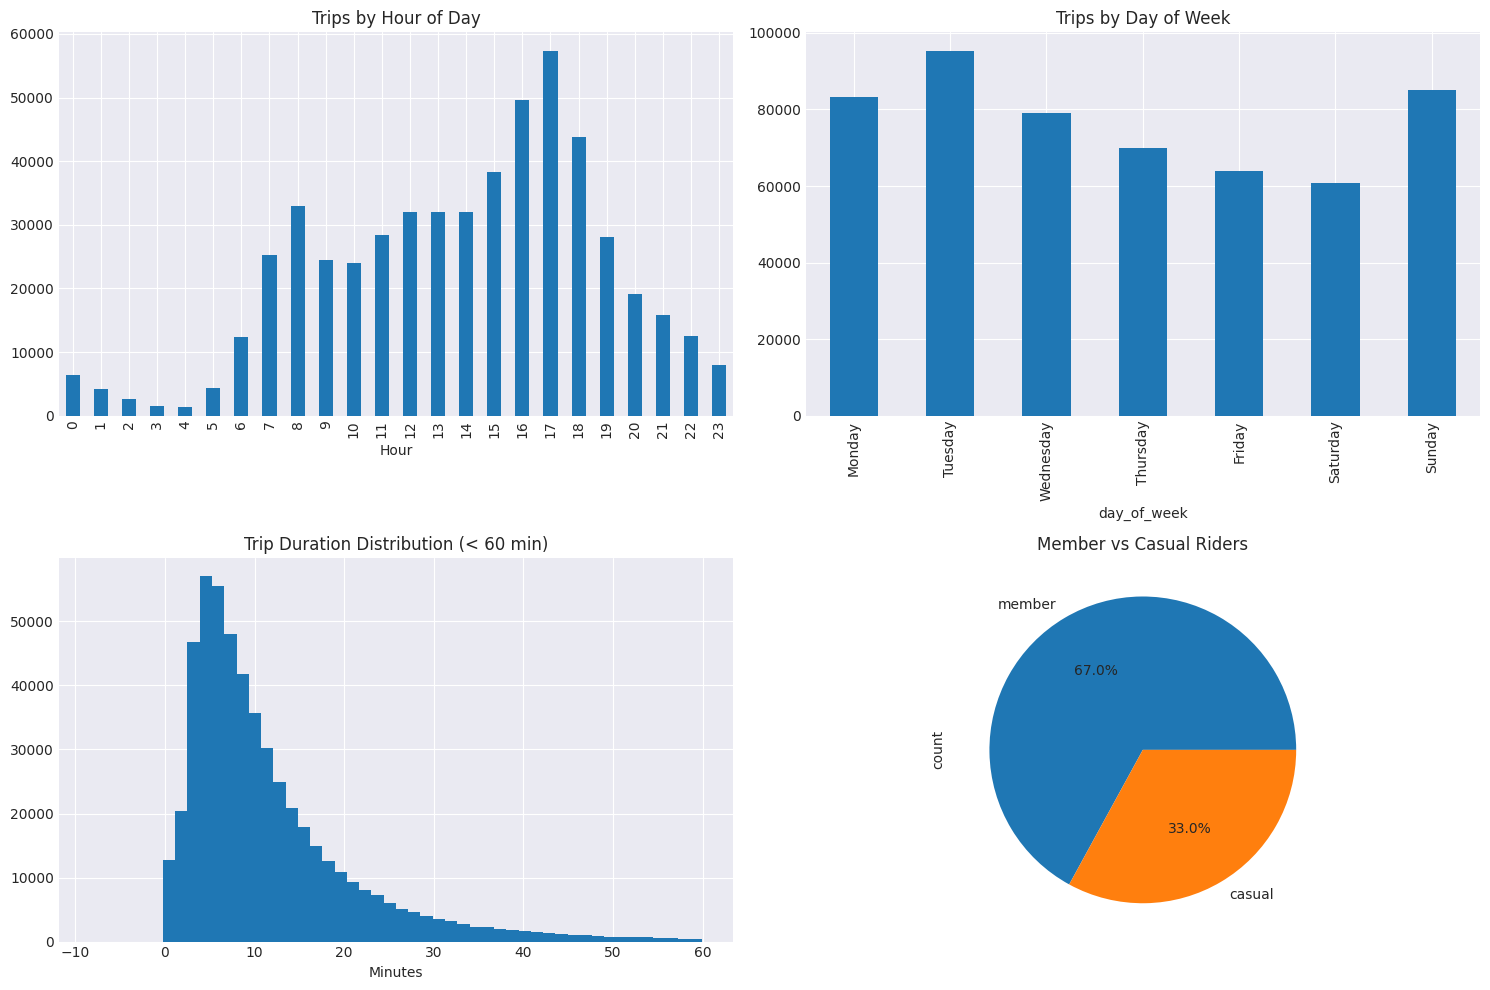

In [11]:
# Visualizations
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Trips by hour
df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Trips by Hour of Day')
axes[0,0].set_xlabel('Hour')

# Trips by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'].value_counts()[day_order].plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Trips by Day of Week')

# Trip duration distribution (filtered outliers)
df[df['trip_duration_min'] < 60]['trip_duration_min'].hist(bins=50, ax=axes[1,0])
axes[1,0].set_title('Trip Duration Distribution (< 60 min)')
axes[1,0].set_xlabel('Minutes')

# Member vs Casual
df['member_casual'].value_counts().plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%')
axes[1,1].set_title('Member vs Casual Riders')

plt.tight_layout()
plt.show()

In [12]:
# Station Analysis
print("Top 10 Start Stations:")
print(df['start_station_name'].value_counts().head(10))

print("\n" + "="*50)
print("Top 10 End Stations:")
print(df['end_station_name'].value_counts().head(10))

Top 10 Start Stations:
start_station_name
University Ave & 57th St             4215
Streeter Dr & Grand Ave              4129
Ellis Ave & 60th St                  3918
Kingsbury St & Kinzie St             3367
Clinton St & Washington Blvd         3307
Clark St & Elm St                    3220
DuSable Lake Shore Dr & Monroe St    3101
Wells St & Concord Ln                2866
Clinton St & Madison St              2854
Wells St & Elm St                    2845
Name: count, dtype: int64

Top 10 End Stations:
end_station_name
Streeter Dr & Grand Ave              4306
University Ave & 57th St             4176
Ellis Ave & 60th St                  3880
Clinton St & Washington Blvd         3452
Kingsbury St & Kinzie St             3250
Clark St & Elm St                    3129
Clinton St & Madison St              3045
Wells St & Concord Ln                2935
Ellis Ave & 55th St                  2898
DuSable Lake Shore Dr & Monroe St    2847
Name: count, dtype: int64


In [13]:
# Data Quality Issues to Address
print("Data Quality Issues Found:")
print(f"1. Missing station names: {df['start_station_name'].isnull().sum()}")
print(f"2. Negative trip durations: {(df['trip_duration_min'] < 0).sum()}")
print(f"3. Very long trips (>24h): {(df['trip_duration_min'] > 1440).sum()}")
print(f"4. Very short trips (<1min): {(df['trip_duration_min'] < 1).sum()}")

Data Quality Issues Found:
1. Missing station names: 84412
2. Negative trip durations: 36
3. Very long trips (>24h): 612
4. Very short trips (<1min): 11693
